## **Import Important Libraries**

In [48]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import  StandardScaler , LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier 
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Conv1D, MaxPooling1D, Flatten
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
from scikeras.wrappers import KerasClassifier
import warnings
warnings.filterwarnings('ignore')

## **Dataset Load**

In [2]:
df = pd.read_csv("mental_health.csv")

In [3]:
# See The first 5 rows 
df.head().T

,0,1,2,3,4
Age,40,33,42,53,32
Gender,Male,Male,Male,Male,Female
Country,USA,India,Other,Germany,India
Education,Some College,Bachelor,High School,Bachelor,Bachelor
Marital_Status,Single,Married,Single,Single,Single
Income_Level,Middle,Middle,Low,Middle,High
Employment_Status,Full-time,Unemployed,Full-time,Unemployed,Student
Work_Hours_Per_Week,27,47,53,42,13
Remote_Work,No,No,No,No,No
Job_Satisfaction,6,6,1,10,4


In [4]:
# See the last 5 rows in this dataset
df.tail().T

,9995,9996,9997,9998,9999
Age,50,18,26,40,42
Gender,Female,Female,Male,Female,Female
Country,India,UK,Brazil,Brazil,Other
Education,High School,Some College,Master,Some College,PhD
Marital_Status,Divorced,Divorced,Married,Single,Married
Income_Level,High,Middle,High,Low,High
Employment_Status,Student,Full-time,Full-time,Full-time,Full-time
Work_Hours_Per_Week,42,33,34,42,44
Remote_Work,No,Yes,No,No,Yes
Job_Satisfaction,4,6,4,3,4


In [5]:
# Dataset columns
df.columns

Index(['Age', 'Gender', 'Country', 'Education', 'Marital_Status',
       'Income_Level', 'Employment_Status', 'Work_Hours_Per_Week',
       'Remote_Work', 'Job_Satisfaction', 'Work_Stress_Level',
       'Work_Life_Balance', 'Ever_Bullied_At_Work',
       'Company_Mental_Health_Support', 'Exercise_Per_Week',
       'Sleep_Hours_Night', 'Caffeine_Drinks_Day', 'Alcohol_Frequency',
       'Smoking', 'Screen_Time_Hours_Day', 'Social_Media_Hours_Day',
       'Hobby_Time_Hours_Week', 'Diet_Quality', 'Financial_Stress',
       'Feeling_Sad_Down', 'Loss_Of_Interest', 'Sleep_Trouble', 'Fatigue',
       'Poor_Appetite_Or_Overeating', 'Feeling_Worthless',
       'Concentration_Difficulty', 'Anxious_Nervous', 'Panic_Attacks',
       'Mood_Swings', 'Irritability', 'Obsessive_Thoughts',
       'Compulsive_Behavior', 'Self_Harm_Thoughts', 'Suicidal_Thoughts',
       'Family_History_Mental_Illness', 'Previously_Diagnosed',
       'Ever_Sought_Treatment', 'On_Therapy_Now', 'On_Medication',
       'Traum

In [6]:
# Dataset Dtype check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Gender                         10000 non-null  object 
 2   Country                        10000 non-null  object 
 3   Education                      10000 non-null  object 
 4   Marital_Status                 10000 non-null  object 
 5   Income_Level                   10000 non-null  object 
 6   Employment_Status              10000 non-null  object 
 7   Work_Hours_Per_Week            10000 non-null  int64  
 8   Remote_Work                    10000 non-null  object 
 9   Job_Satisfaction               10000 non-null  int64  
 10  Work_Stress_Level              10000 non-null  int64  
 11  Work_Life_Balance              10000 non-null  int64  
 12  Ever_Bullied_At_Work           10000 non-null  

In [7]:
# Statistical Analysis
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,34.94790,11.156390,18.0,26.0,34.0,43.0,75.0
Work_Hours_Per_Week,10000.0,39.65790,10.016711,0.0,33.0,40.0,46.0,74.0
Job_Satisfaction,10000.0,5.50270,2.884341,1.0,3.0,6.0,8.0,10.0
Work_Stress_Level,10000.0,5.49390,2.881630,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,10000.0,5.48940,2.875572,1.0,3.0,5.0,8.0,10.0
Ever_Bullied_At_Work,10000.0,0.24740,0.431523,0.0,0.0,0.0,0.0,1.0
Sleep_Hours_Night,10000.0,6.81545,1.377975,3.0,5.9,6.8,7.7,11.0
Caffeine_Drinks_Day,10000.0,2.02330,1.427432,0.0,1.0,2.0,3.0,8.0
Screen_Time_Hours_Day,10000.0,7.06459,2.955874,1.0,5.0,7.0,9.1,16.0
Social_Media_Hours_Day,10000.0,3.14181,2.254204,0.0,1.3,3.0,4.7,12.0


In [8]:
df.dtypes

Age                                int64
Gender                            object
Country                           object
Education                         object
Marital_Status                    object
Income_Level                      object
Employment_Status                 object
Work_Hours_Per_Week                int64
Remote_Work                       object
Job_Satisfaction                   int64
Work_Stress_Level                  int64
Work_Life_Balance                  int64
Ever_Bullied_At_Work               int64
Company_Mental_Health_Support     object
Exercise_Per_Week                 object
Sleep_Hours_Night                float64
Caffeine_Drinks_Day                int64
Alcohol_Frequency                 object
Smoking                           object
Screen_Time_Hours_Day            float64
Social_Media_Hours_Day           float64
Hobby_Time_Hours_Week              int64
Diet_Quality                      object
Financial_Stress                   int64
Feeling_Sad_Down

## **EDA**

In [9]:
# Check the missing values in this dataset
df.isna().sum()

Age                              0
Gender                           0
Country                          0
Education                        0
Marital_Status                   0
Income_Level                     0
Employment_Status                0
Work_Hours_Per_Week              0
Remote_Work                      0
Job_Satisfaction                 0
Work_Stress_Level                0
Work_Life_Balance                0
Ever_Bullied_At_Work             0
Company_Mental_Health_Support    0
Exercise_Per_Week                0
Sleep_Hours_Night                0
Caffeine_Drinks_Day              0
Alcohol_Frequency                0
Smoking                          0
Screen_Time_Hours_Day            0
Social_Media_Hours_Day           0
Hobby_Time_Hours_Week            0
Diet_Quality                     0
Financial_Stress                 0
Feeling_Sad_Down                 0
Loss_Of_Interest                 0
Sleep_Trouble                    0
Fatigue                          0
Poor_Appetite_Or_Ove

In [10]:
#Check duplicate values
df.duplicated().sum()

np.int64(0)

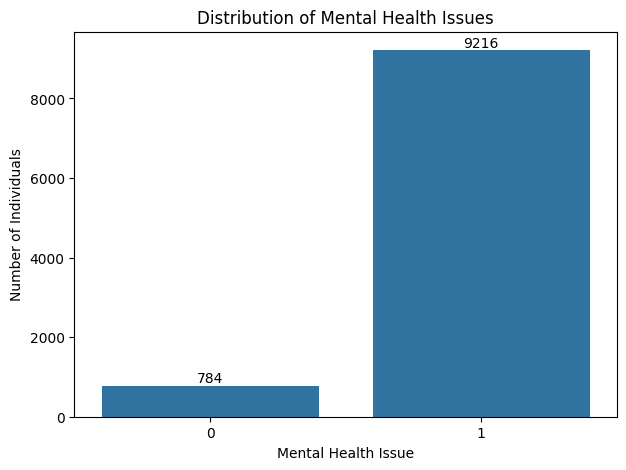

In [11]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x='Has_Mental_Health_Issue'
)

plt.title('Distribution of Mental Health Issues')
plt.xlabel('Mental Health Issue')
plt.ylabel('Number of Individuals')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

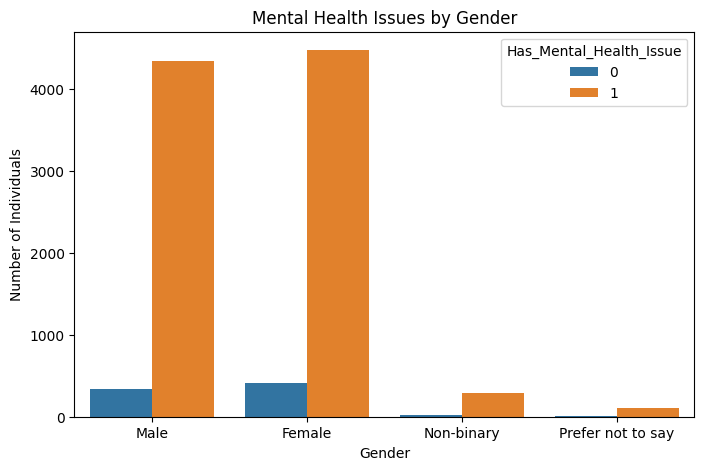

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Has_Mental_Health_Issue'
)

plt.title('Mental Health Issues by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Individuals')

plt.show()

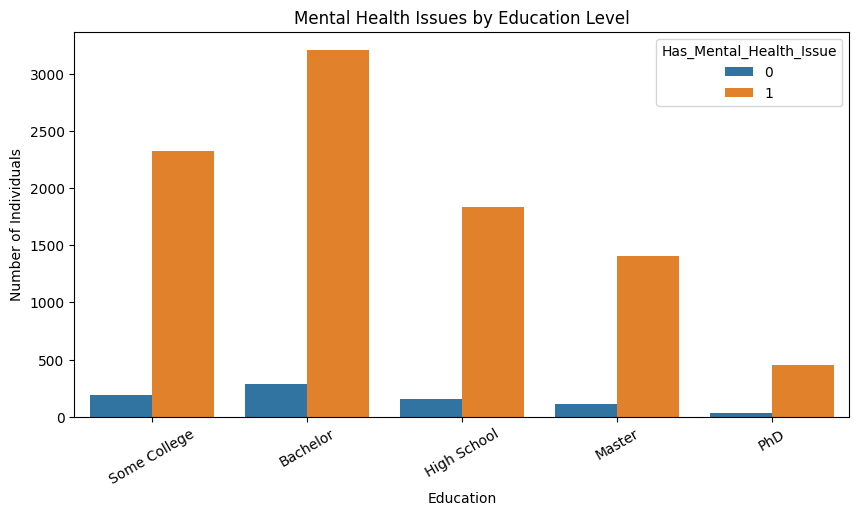

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Education',
    hue='Has_Mental_Health_Issue'
)

plt.title('Mental Health Issues by Education Level')
plt.xticks(rotation=30)
plt.xlabel('Education')
plt.ylabel('Number of Individuals')

plt.show()

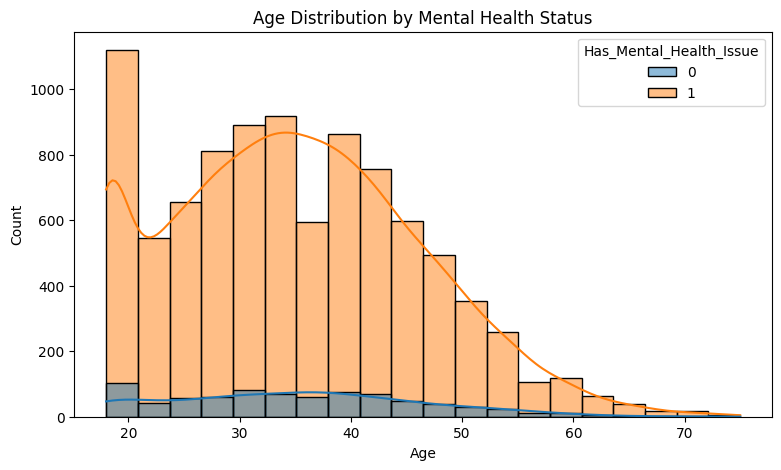

In [14]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Has_Mental_Health_Issue',
    kde=True,
    bins=20
)

plt.title('Age Distribution by Mental Health Status')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

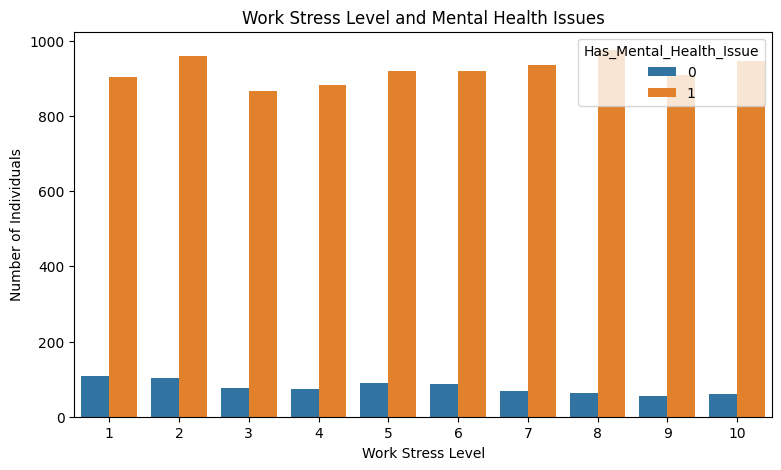

In [15]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Work_Stress_Level',
    hue='Has_Mental_Health_Issue'
)

plt.title('Work Stress Level and Mental Health Issues')
plt.xlabel('Work Stress Level')
plt.ylabel('Number of Individuals')

plt.show()

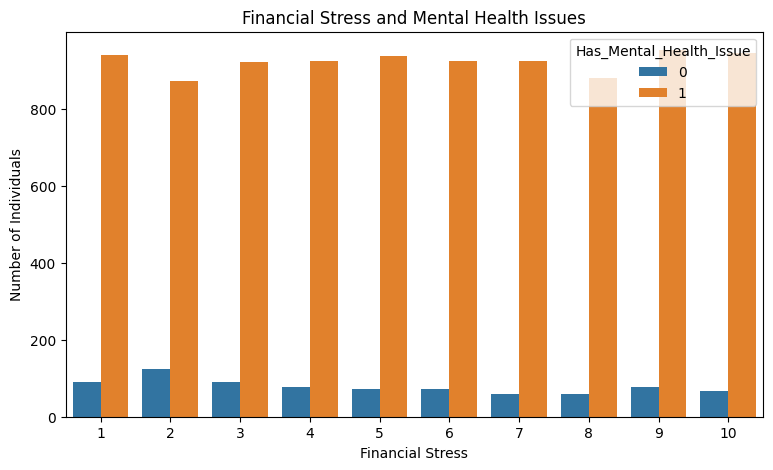

In [16]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Financial_Stress',
    hue='Has_Mental_Health_Issue'
)

plt.title('Financial Stress and Mental Health Issues')
plt.xlabel('Financial Stress')
plt.ylabel('Number of Individuals')

plt.show()

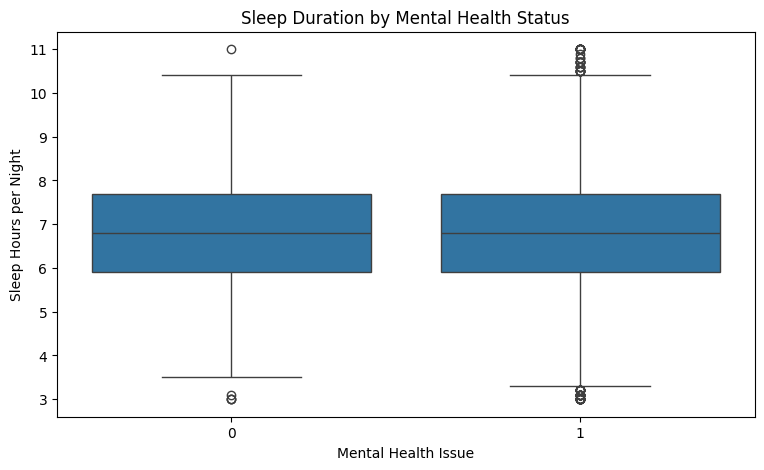

In [17]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x='Has_Mental_Health_Issue',
    y='Sleep_Hours_Night'
)

plt.title('Sleep Duration by Mental Health Status')
plt.xlabel('Mental Health Issue')
plt.ylabel('Sleep Hours per Night')

plt.show()

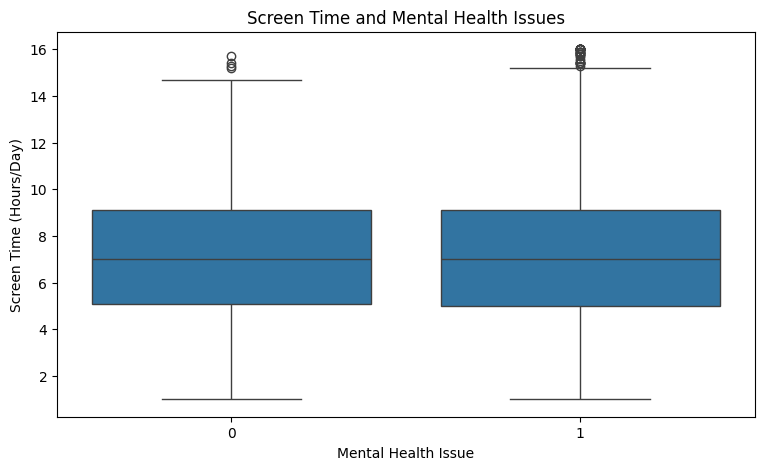

In [18]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x='Has_Mental_Health_Issue',
    y='Screen_Time_Hours_Day'
)

plt.title('Screen Time and Mental Health Issues')
plt.xlabel('Mental Health Issue')
plt.ylabel('Screen Time (Hours/Day)')

plt.show()

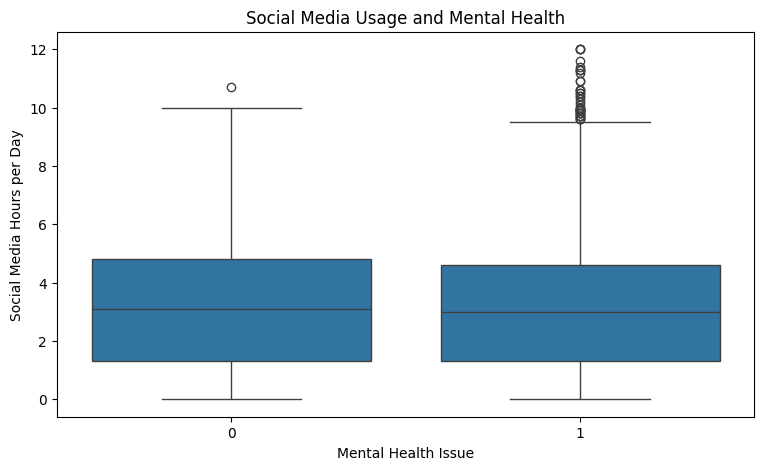

In [19]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x='Has_Mental_Health_Issue',
    y='Social_Media_Hours_Day'
)

plt.title('Social Media Usage and Mental Health')
plt.xlabel('Mental Health Issue')
plt.ylabel('Social Media Hours per Day')

plt.show()

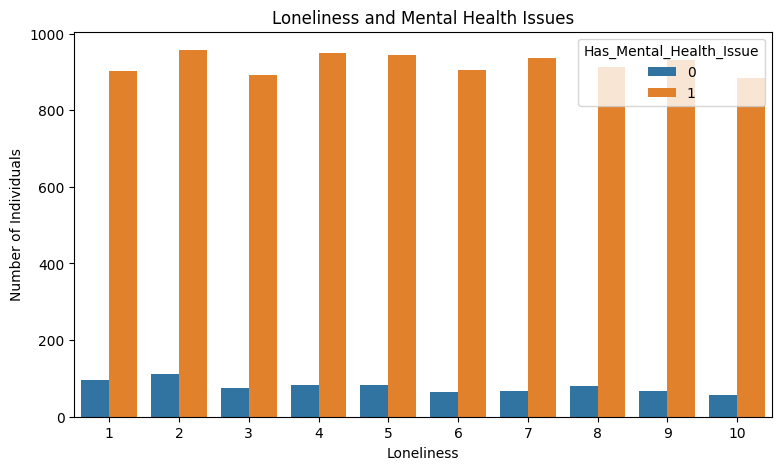

In [20]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Loneliness',
    hue='Has_Mental_Health_Issue'
)

plt.title('Loneliness and Mental Health Issues')
plt.xlabel('Loneliness')
plt.ylabel('Number of Individuals')

plt.show()

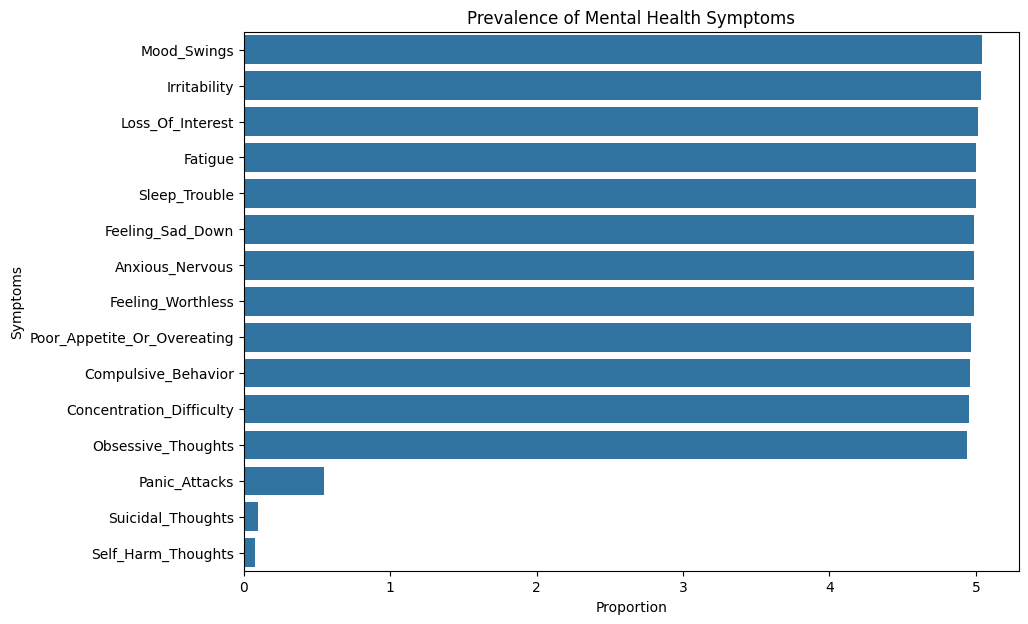

In [21]:
symptom_cols = [
    'Feeling_Sad_Down',
    'Loss_Of_Interest',
    'Sleep_Trouble',
    'Fatigue',
    'Poor_Appetite_Or_Overeating',
    'Feeling_Worthless',
    'Concentration_Difficulty',
    'Anxious_Nervous',
    'Panic_Attacks',
    'Mood_Swings',
    'Irritability',
    'Obsessive_Thoughts',
    'Compulsive_Behavior',
    'Self_Harm_Thoughts',
    'Suicidal_Thoughts'
]

symptom_rate = df[symptom_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10,7))

sns.barplot(
    x=symptom_rate.values,
    y=symptom_rate.index
)

plt.title('Prevalence of Mental Health Symptoms')
plt.xlabel('Proportion')
plt.ylabel('Symptoms')

plt.show()

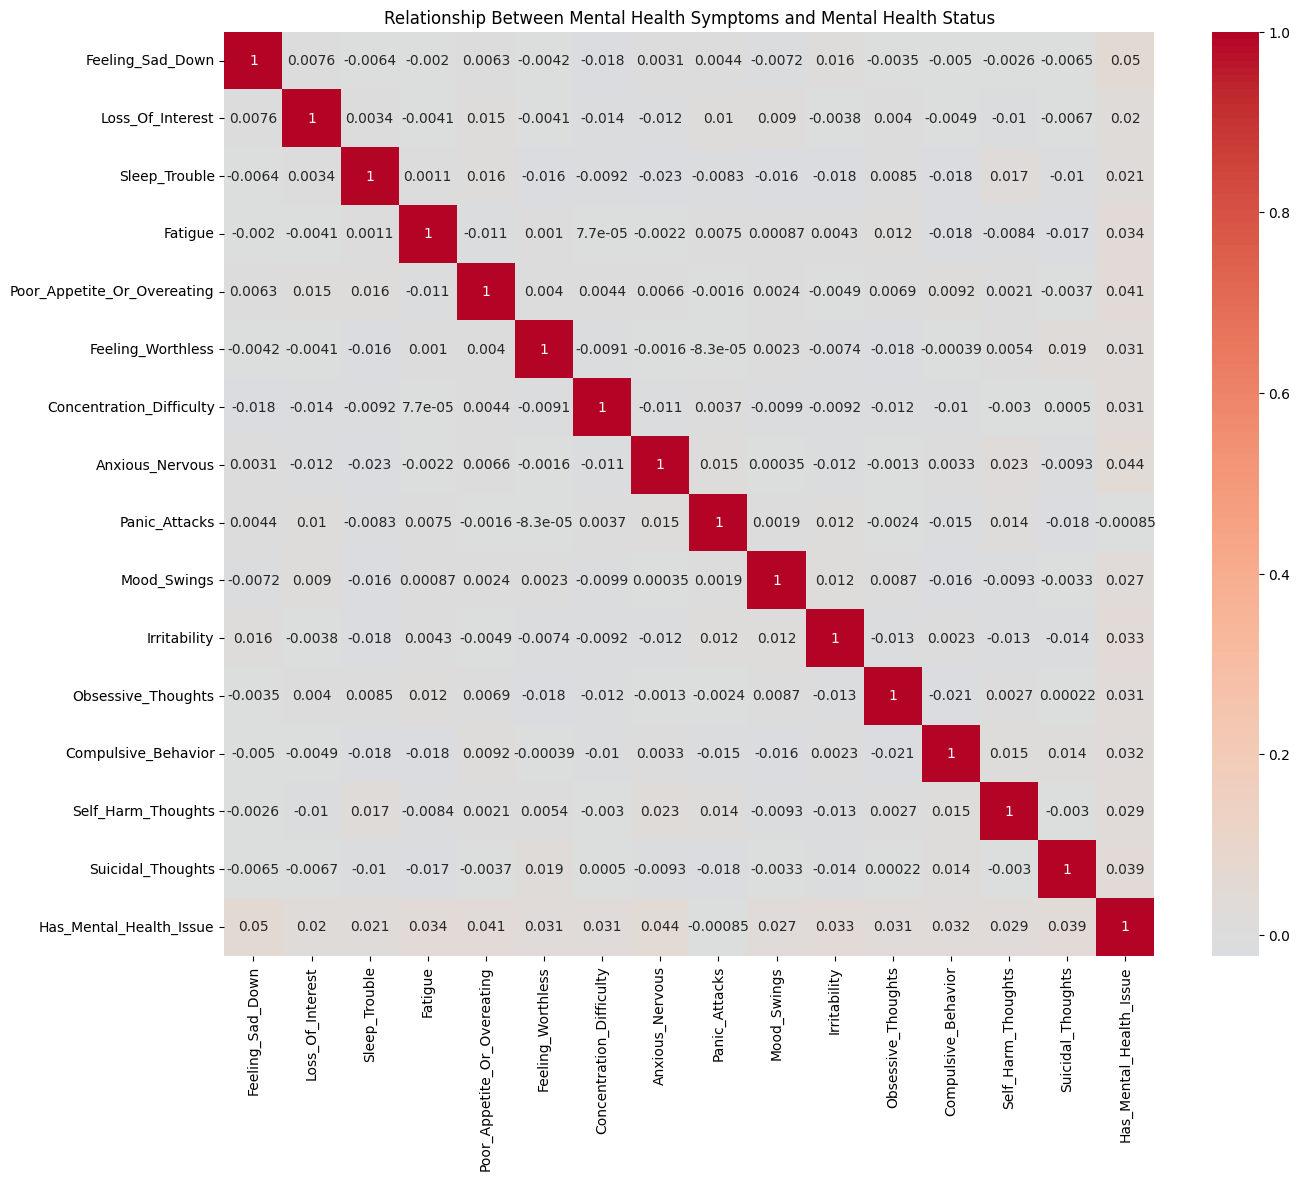

In [22]:
symptom_target = df[symptom_cols + ['Has_Mental_Health_Issue']].corr()

plt.figure(figsize=(15,12))

sns.heatmap(symptom_target,annot=True,cmap='coolwarm',center=0)

plt.title('Relationship Between Mental Health Symptoms and Mental Health Status')

plt.show()

In [23]:
# Performing Label Encoder 
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))
print("Encoding Successfully Done!")

print("After Encoding See the Dtype for this Dataset:")
df.info()

Encoding Successfully Done!
After Encoding See the Dtype for this Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Gender                         10000 non-null  int64  
 2   Country                        10000 non-null  int64  
 3   Education                      10000 non-null  int64  
 4   Marital_Status                 10000 non-null  int64  
 5   Income_Level                   10000 non-null  int64  
 6   Employment_Status              10000 non-null  int64  
 7   Work_Hours_Per_Week            10000 non-null  int64  
 8   Remote_Work                    10000 non-null  int64  
 9   Job_Satisfaction               10000 non-null  int64  
 10  Work_Stress_Level              10000 non-null  int64  
 11  Work_Life_Balance              1

In [24]:
# Data spliting
x = df.drop(['Has_Mental_Health_Issue'],axis = 1)
y = df['Has_Mental_Health_Issue']

In [25]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y,train_size = .25,random_state = 42)

In [26]:
from imblearn.over_sampling import SMOTE
#  SMOTE
smote = SMOTE(random_state=42)

xtrain, ytrain = smote.fit_resample(xtrain, ytrain)

print("After SMOTE:")
print(ytrain.value_counts())

print("\nTest:")
print(ytest.value_counts())

After SMOTE:
Has_Mental_Health_Issue
1    2313
0    2313
Name: count, dtype: int64

Test:
Has_Mental_Health_Issue
1    6903
0     597
Name: count, dtype: int64


## **Logistic Regression**

Model 1 Training Score :  86.18677042801556
Model 1 Testing Score :  80.28


accuracy_score For Model 1 :  80.28
Classification Report for Model 1 :                precision    recall  f1-score   support

           0       0.13      0.26      0.17       597
           1       0.93      0.85      0.89      6903

    accuracy                           0.80      7500
   macro avg       0.53      0.55      0.53      7500
weighted avg       0.87      0.80      0.83      7500



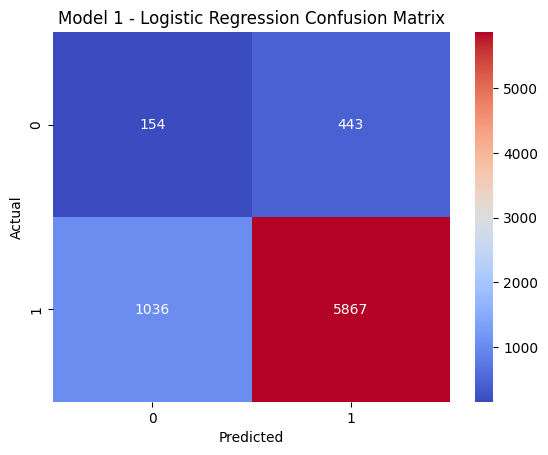

In [27]:
lg = LogisticRegression()

model_1_lg =lg.fit(xtrain,ytrain)

#Training score 
print("Model 1 Training Score : ", model_1_lg.score(xtrain,ytrain)*100)

#Testing score 
print("Model 1 Testing Score : ", model_1_lg.score(xtest,ytest)*100)

# prediciton
y_pred_lg = lg.predict(xtest)
print('\n')

# Accuracy score 
ac_score_lg = accuracy_score(ytest,y_pred_lg)
print("accuracy_score For Model 1 : ", ac_score_lg*100)

#classification report
class_rep_lg = classification_report(ytest, y_pred_lg)
print("Classification Report for Model 1 : ", class_rep_lg)

#confusion matrix
con_max_lg = confusion_matrix(ytest,y_pred_lg)
# Heatmap for confusion matrix
sns.heatmap(con_max_lg, annot=True,fmt='d',cmap="coolwarm")
plt.title("Model 1 - Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40, 'bootstrap': False}

Best CV Score:
95.8063121487246

Model  Training Score: 100.0
Model  Testing Score: 91.42666666666666

Accuracy Score : 91.42666666666666

Classification Report :
               precision    recall  f1-score   support

           0       0.19      0.02      0.04       597
           1       0.92      0.99      0.96      6903

    accuracy                           0.91      7500
   macro avg       0.56      0.51      0.50      7500
weighted avg       0.86      0.91      0.88      7500



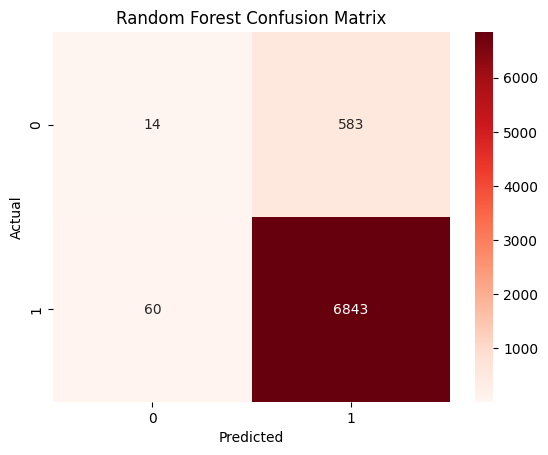

In [28]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

# Hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Hyperparameter Tuning
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest CV Score:")
print(rf_random.best_score_ * 100)

# Best Random Forest Model
model_1_rf = rf_random.best_estimator_

# Training score
print("\nModel  Training Score:",
      model_1_rf.score(xtrain, ytrain) * 100)

# Testing score
print("Model  Testing Score:",
      model_1_rf.score(xtest, ytest) * 100)

# Prediction
y_pred_rf = model_1_rf.predict(xtest)

# Accuracy
ac_score_rf = accuracy_score(ytest, y_pred_rf)
print("\nAccuracy Score :",
      ac_score_rf * 100)

# Classification Report
class_rep_rf = classification_report(ytest, y_pred_rf)
print("\nClassification Report :\n",
      class_rep_rf)

# Confusion Matrix
con_max_rf = confusion_matrix(ytest, y_pred_rf)

sns.heatmap(con_max_rf, annot=True, fmt='d', cmap="Reds")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Best Parameters:
{'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20, 'criterion': 'entropy'}

Best CV Score:
85.7976653696498

 Training Score: 97.55728491137052
 Testing Score: 78.45333333333333

Accuracy Score : 78.45333333333333

Classification Report :
               precision    recall  f1-score   support

           0       0.09      0.18      0.12       597
           1       0.92      0.84      0.88      6903

    accuracy                           0.78      7500
   macro avg       0.50      0.51      0.50      7500
weighted avg       0.86      0.78      0.82      7500



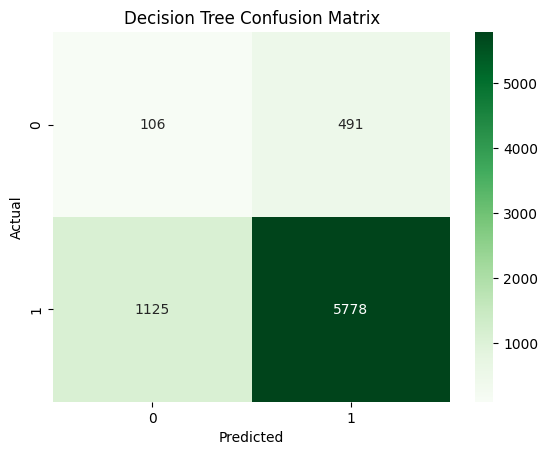

In [29]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2'],
    'splitter': ['best', 'random']
}

# Hyperparameter Tuning
dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

dt_random.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters:")
print(dt_random.best_params_)

print("\nBest CV Score:")
print(dt_random.best_score_ * 100)

# Best Decision Tree Model
model_1_dt = dt_random.best_estimator_

# Training Score
print("\n Training Score:",
      model_1_dt.score(xtrain, ytrain) * 100)

# Testing Score
print(" Testing Score:",
      model_1_dt.score(xtest, ytest) * 100)

# Prediction
y_pred_dt = model_1_dt.predict(xtest)

# Accuracy
ac_score_dt = accuracy_score(ytest, y_pred_dt)
print("\nAccuracy Score :",
      ac_score_dt * 100)

# Classification Report
class_rep_dt = classification_report(ytest, y_pred_dt)
print("\nClassification Report :\n",
      class_rep_dt)

# Confusion Matrix
con_max_dt = confusion_matrix(ytest, y_pred_dt)

sns.heatmap(con_max_dt, annot=True, fmt='d', cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 12, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}

Best CV Score:
95.22265456117597

 Training Score: 100.0
 Testing Score: 90.70666666666666

Accuracy Score : 90.70666666666666

Classification Report :
               precision    recall  f1-score   support

           0       0.19      0.05      0.08       597
           1       0.92      0.98      0.95      6903

    accuracy                           0.91      7500
   macro avg       0.56      0.52      0.52      7500
weighted avg       0.86      0.91      0.88      7500



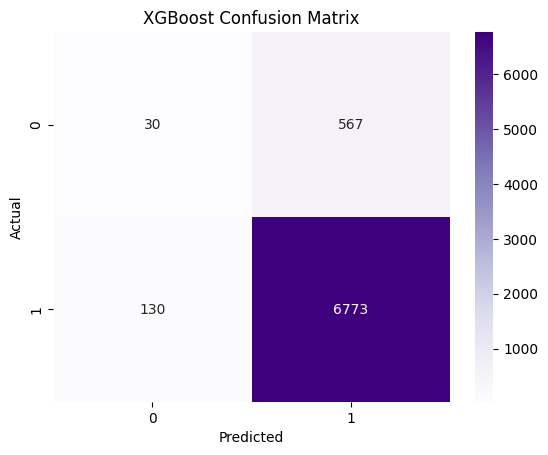

In [30]:
# XGBoost
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7, 10],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.1, 1, 5, 10]
}

# Hyperparameter Tuning
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=40,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters:")
print(xgb_random.best_params_)

print("\nBest CV Score:")
print(xgb_random.best_score_ * 100)

# Best XGBoost Model
model_1_xgb = xgb_random.best_estimator_

# Training Score
print("\n Training Score:",
      model_1_xgb.score(xtrain, ytrain) * 100)

# Testing Score
print(" Testing Score:",
      model_1_xgb.score(xtest, ytest) * 100)

# Prediction
y_pred_xgb = model_1_xgb.predict(xtest)

# Accuracy
ac_score_xgb = accuracy_score(ytest, y_pred_xgb)
print("\nAccuracy Score :",
      ac_score_xgb * 100)

# Classification Report
class_rep_xgb = classification_report(ytest, y_pred_xgb)
print("\nClassification Report :\n",
      class_rep_xgb)

# Confusion Matrix
con_max_xgb = confusion_matrix(ytest, y_pred_xgb)

sns.heatmap(con_max_xgb, annot=True, fmt='d', cmap="Purples")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Parameters:
{'random_strength': 0, 'loss_function': 'MultiClass', 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 700, 'depth': 10, 'border_count': 128, 'bagging_temperature': 5}

Best CV Score:
96.00086467790749

 Training Score: 100.0
 Testing Score: 89.77333333333334

Accuracy Score : 89.77333333333334

Classification Report :
               precision    recall  f1-score   support

           0       0.13      0.05      0.07       597
           1       0.92      0.97      0.95      6903

    accuracy                           0.90      7500
   macro avg       0.53      0.51      0.51      7500
weighted avg       0.86      0.90      0.88      7500



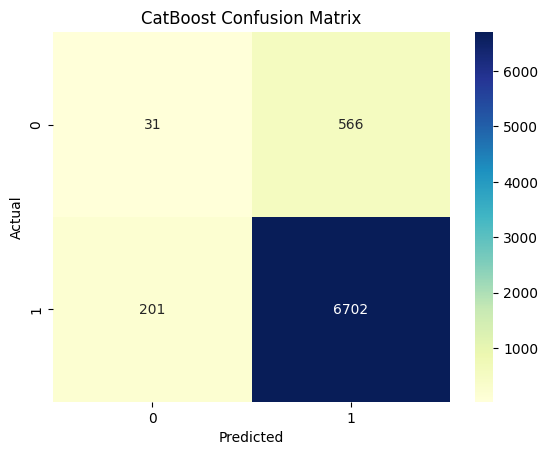

In [31]:
from catboost import CatBoostClassifier

# CatBoost
cat = CatBoostClassifier(
    random_seed=42,
    verbose=0
)

# Hyperparameters
param_grid = {
    'iterations': [100, 200, 300, 500, 700, 1000],
    'depth': [4, 5, 6, 7, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'border_count': [32, 64, 128, 254],
    'random_strength': [0, 0.5, 1, 2, 5],
    'bagging_temperature': [0, 0.5, 1, 2, 5],
    'loss_function': ['MultiClass']
}

# Hyperparameter Tuning
cat_random = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_grid,
    n_iter=40,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

cat_random.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters:")
print(cat_random.best_params_)

print("\nBest CV Score:")
print(cat_random.best_score_ * 100)

# Best CatBoost Model
model_1_cat = cat_random.best_estimator_

# Training Score
print("\n Training Score:",
      model_1_cat.score(xtrain, ytrain) * 100)

# Testing Score
print(" Testing Score:",
      model_1_cat.score(xtest, ytest) * 100)

# Prediction
y_pred_cat = model_1_cat.predict(xtest)

# Accuracy
ac_score_cat = accuracy_score(ytest, y_pred_cat)
print("\nAccuracy Score :",
      ac_score_cat * 100)

# Classification Report
class_rep_cat = classification_report(ytest, y_pred_cat)
print("\nClassification Report :\n",
      class_rep_cat)

# Confusion Matrix
con_max_cat = confusion_matrix(ytest, y_pred_cat)

sns.heatmap(con_max_cat, annot=True, fmt='d', cmap="YlGnBu")

plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Parameters:
{'n_estimators': 500, 'learning_rate': 1.0, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 1, 'estimator__max_features': None, 'estimator__max_depth': 4}

Best CV Score:
95.48205793341981

Training Score: 100.0
Testing Score: 90.05333333333333

Accuracy Score: 90.05333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.16      0.06      0.09       597
           1       0.92      0.97      0.95      6903

    accuracy                           0.90      7500
   macro avg       0.54      0.52      0.52      7500
weighted avg       0.86      0.90      0.88      7500



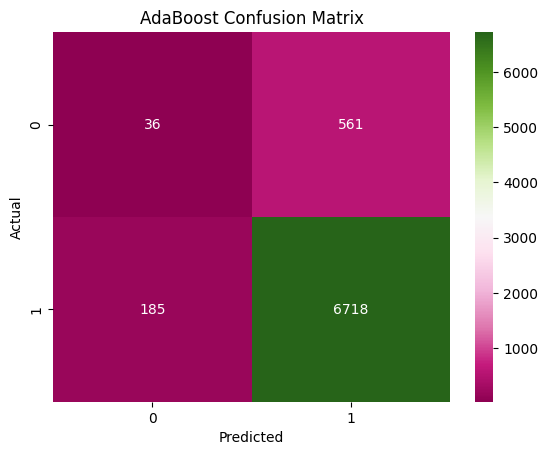

In [36]:
# AdaBoost
base_tree = DecisionTreeClassifier(random_state=42)

ada = AdaBoostClassifier(estimator=base_tree,random_state=42)

# Hyperparameters
param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0],

    # Decision Tree parameters
    'estimator__max_depth': [1, 2, 3, 4, 5],
    'estimator__min_samples_split': [2, 5, 10, 15, 20],
    'estimator__min_samples_leaf': [1, 2, 5, 10],
    'estimator__max_features': ['sqrt', 'log2', None]
}

# Hyperparameter Tuning
ada_random = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_grid,
    n_iter=40,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

ada_random.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters:")
print(ada_random.best_params_)

print("\nBest CV Score:")
print(ada_random.best_score_ * 100)

# Best AdaBoost Model
model_1_ada = ada_random.best_estimator_

# Training Score
print("\nTraining Score:", model_1_ada.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score:",model_1_ada.score(xtest, ytest) * 100)

# Prediction
y_pred_ada = model_1_ada.predict(xtest)

# Accuracy
ac_score_ada = accuracy_score(ytest, y_pred_ada)

print("\nAccuracy Score:",ac_score_ada * 100)

# Classification Report
class_rep_ada = classification_report(ytest, y_pred_ada)

print("\nClassification Report:\n",class_rep_ada)

# Confusion Matrix
con_max_ada = confusion_matrix(ytest, y_pred_ada)

sns.heatmap(con_max_ada,annot=True,fmt='d', cmap="PiYG")

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Parameters:
{'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 0.01, 'num_leaves': 70, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Best CV Score:
95.56852572416776

Training Score: 100.0
Testing Score: 90.68

Accuracy Score: 90.68

Classification Report:
               precision    recall  f1-score   support

           0       0.19      0.05      0.08       597
           1       0.92      0.98      0.95      6903

    accuracy                           0.91      7500
   macro avg       0.55      0.52      0.51      7500
weighted avg       0.86      0.91      0.88      7500



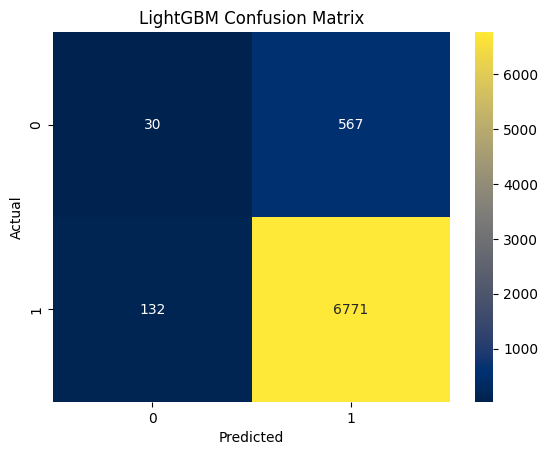

In [40]:
# LightGBM
lgbm = LGBMClassifier(random_state=42,verbose=-1)
# Hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [-1, 3, 5, 7, 10],
    'num_leaves': [15, 31, 50, 70, 100],
    'min_child_samples': [10, 20, 30, 50, 100],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 5],
    'reg_lambda': [0, 0.01, 0.1, 1, 5]
}

# Hyperparameter Tuning
lgbm_random = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=40,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_random.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters:")
print(lgbm_random.best_params_)

print("\nBest CV Score:")
print(lgbm_random.best_score_ * 100)

# Best LightGBM Model
model_1_lgbm = lgbm_random.best_estimator_

# Training Score
print("\nTraining Score:", model_1_lgbm.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score:", model_1_lgbm.score(xtest, ytest) * 100)

# Prediction
y_pred_lgbm = model_1_lgbm.predict(xtest)

# Accuracy
ac_score_lgbm = accuracy_score(ytest, y_pred_lgbm)

print("\nAccuracy Score:",ac_score_lgbm * 100)

# Classification Report
class_rep_lgbm = classification_report(ytest, y_pred_lgbm)

print("\nClassification Report:\n",class_rep_lgbm)

# Confusion Matrix
con_max_lgbm = confusion_matrix(ytest, y_pred_lgbm)

sns.heatmap(con_max_lgbm,annot=True,fmt='d',cmap="cividis")

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'model__units2': 128, 'model__units1': 128, 'model__learning_rate': 0.01, 'model__dropout': 0.4, 'epochs': 50, 'batch_size': 64}

Best CV Score:
91.56939040207523

Training Score: 98.46519671422396
Testing Score: 86.10666666666667

Accuracy Score: 86.10666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.12      0.12       597
           1       0.92      0.93      0.92      6903

    accuracy                           0.86      7500
   macro avg       0.52      0.52      0.52      7500
weighted avg       0.86      0.86      0.86      7500



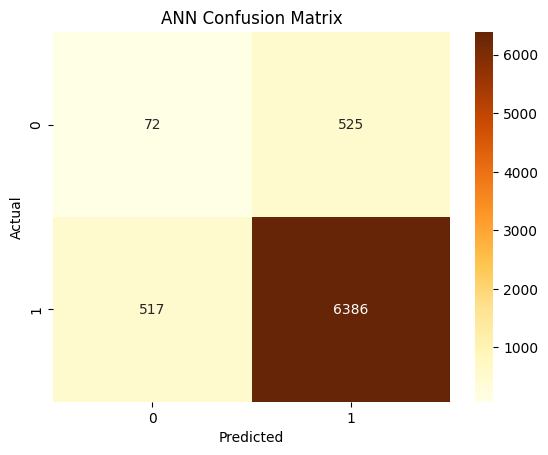

In [47]:
# ANN Model
def create_ann(units1=64, units2=32,dropout=0.2,learning_rate=0.001):
    
    model = Sequential([
        Dense(units1, activation='relu', input_shape=(xtrain.shape[1],)),
        Dropout(dropout),

        Dense(units2, activation='relu'),
        Dropout(dropout),

        Dense(len(ytrain.unique()), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ANN
ann = KerasClassifier(
    model=create_ann,
    epochs=20,
    batch_size=32,
    verbose=0
)


# Hyperparameters
param_grid = {
    'model__units1': [32, 64, 128, 256],
    'model__units2': [16, 32, 64, 128],
    'model__dropout': [0.1, 0.2, 0.3, 0.4],
    'model__learning_rate': [0.001, 0.01, 0.0001],
    'batch_size': [32, 64, 128],
    'epochs': [10, 20, 30, 50]
}


# Hyperparameter Tuning
ann_random = RandomizedSearchCV(
    estimator=ann,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1,
    verbose=1
)


ann_random.fit(xtrain, ytrain)


# Best Parameters
print("Best Parameters:")
print(ann_random.best_params_)

print("\nBest CV Score:")
print(ann_random.best_score_ * 100)


# Best ANN Model
model_1_ann = ann_random.best_estimator_


# Training Score
print("\nTraining Score:",model_1_ann.score(xtrain, ytrain) * 100)


# Testing Score
print("Testing Score:",model_1_ann.score(xtest, ytest) * 100)


# Prediction
y_pred_ann = model_1_ann.predict(xtest)


# Accuracy
ac_score_ann = accuracy_score(ytest, y_pred_ann)

print("\nAccuracy Score:",ac_score_ann * 100)


# Classification Report
class_rep_ann = classification_report(ytest,y_pred_ann)

print("\nClassification Report:\n",class_rep_ann)


# Confusion Matrix
con_max_ann = confusion_matrix(ytest,y_pred_ann)

sns.heatmap(con_max_ann,annot=True,fmt='d',cmap="YlOrBr")

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'model__kernel_size': 3, 'model__filters': 16, 'model__dropout': 0.1, 'model__dense_units': 128, 'epochs': 50, 'batch_size': 32}

Best CV Score:
92.65023778642455

Training Score: 99.43795936013835
Testing Score: 83.81333333333333

Accuracy Score: 83.81333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.16      0.14       597
           1       0.92      0.90      0.91      6903

    accuracy                           0.84      7500
   macro avg       0.52      0.53      0.52      7500
weighted avg       0.86      0.84      0.85      7500



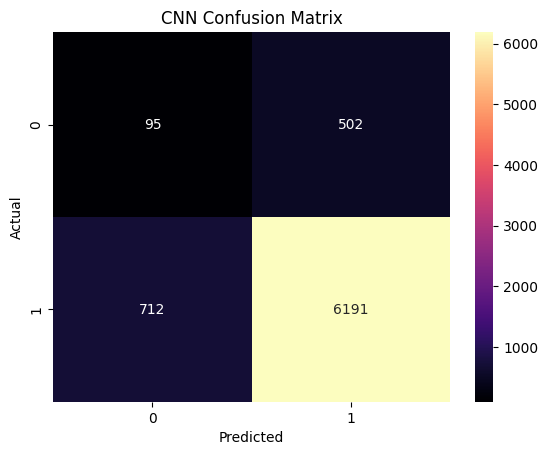

In [ ]:
# CNN Model
def create_cnn(
    filters=32,
    kernel_size=3,
    dense_units=64,
    dropout=0.2
):
    
    model = Sequential([
        Conv1D( filters=filters,kernel_size=kernel_size,activation='relu', input_shape=(xtrain.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout),
        Dense(len(ytrain.unique()), activation='softmax')])

    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    return model


# Reshape data for CNN

xtrain_cnn = xtrain.values.reshape(xtrain.shape[0],xtrain.shape[1], 1)
xtest_cnn = xtest.values.reshape(xtest.shape[0],xtest.shape[1],1)


# CNN Classifier
cnn = KerasClassifier(model=create_cnn,epochs=20,batch_size=32,verbose=0)


# Hyperparameters
param_grid = {
    'model__filters': [16, 32, 64, 128],
    'model__kernel_size': [2, 3, 5],
    'model__dense_units': [32, 64, 128],
    'model__dropout': [0.1, 0.2, 0.3, 0.4],
    'batch_size': [32, 64, 128],
    'epochs': [10, 20, 30, 50]
}


# Hyperparameter Tuning
cnn_random = RandomizedSearchCV(
    estimator=cnn,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1,
    verbose=1
)


cnn_random.fit(xtrain_cnn, ytrain)


# Best Parameters
print("Best Parameters:")
print(cnn_random.best_params_)

print("\nBest CV Score:")
print(cnn_random.best_score_ * 100)


# Best CNN Model
model_1_cnn = cnn_random.best_estimator_


# Training Score
print("\nTraining Score:",model_1_cnn.score(xtrain_cnn, ytrain) * 100)


# Testing Score
print("Testing Score:",model_1_cnn.score(xtest_cnn, ytest) * 100)


# Prediction
y_pred_cnn = model_1_cnn.predict(xtest_cnn)


# Accuracy
ac_score_cnn = accuracy_score( ytest, y_pred_cnn)

print("\nAccuracy Score:", ac_score_cnn * 100)


# Classification Report
class_rep_cnn = classification_report(ytest,y_pred_cnn)

print("\nClassification Report:\n", class_rep_cnn)

# Confusion Matrix
con_max_cnn = confusion_matrix(ytest, y_pred_cnn)

sns.heatmap(con_max_cnn,annot=True,fmt='d',cmap='magma')

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "XGBoost",
        "CatBoost",
        "AdaBoost",
        "LightGBM",
        "ANN",
        "CNN"
    ],
    
    "Accuracy (%)": [
        80.28,
        91.43,
        78.45,
        90.71,
        89.77,
        90.05,
        90.68,
        86.11,
        83.81
    ],
    
    "Macro F1": [
        0.53,
        0.50,
        0.50,
        0.52,
        0.51,
        0.52,
        0.51,
        0.52,
        0.52
    ],
    
    "Class 0 Precision": [
        0.13,
        0.19,
        0.09,
        0.19,
        0.13,
        0.16,
        0.19,
        0.12,
        0.12
    ],
    
    "Class 0 Recall": [
        0.26,
        0.02,
        0.18,
        0.05,
        0.05,
        0.06,
        0.05,
        0.12,
        0.16
    ],
    
    "Class 0 F1": [
        0.17,
        0.04,
        0.12,
        0.08,
        0.07,
        0.09,
        0.08,
        0.12,
        0.14
    ],
    
    "Class 1 Recall": [
        0.85,
        0.99,
        0.84,
        0.98,
        0.97,
        0.97,
        0.98,
        0.93,
        0.90
    ]
})

model_comparison

,Model,Accuracy (%),Macro F1,Class 0 Precision,Class 0 Recall,Class 0 F1,Class 1 Recall
0,Logistic Regression,80.28,0.53,0.13,0.26,0.17,0.85
1,Random Forest,91.43,0.50,0.19,0.02,0.04,0.99
2,Decision Tree,78.45,0.50,0.09,0.18,0.12,0.84
3,XGBoost,90.71,0.52,0.19,0.05,0.08,0.98
4,CatBoost,89.77,0.51,0.13,0.05,0.07,0.97
5,AdaBoost,90.05,0.52,0.16,0.06,0.09,0.97
6,LightGBM,90.68,0.51,0.19,0.05,0.08,0.98
7,ANN,86.11,0.52,0.12,0.12,0.12,0.93
8,CNN,83.81,0.52,0.12,0.16,0.14,0.90


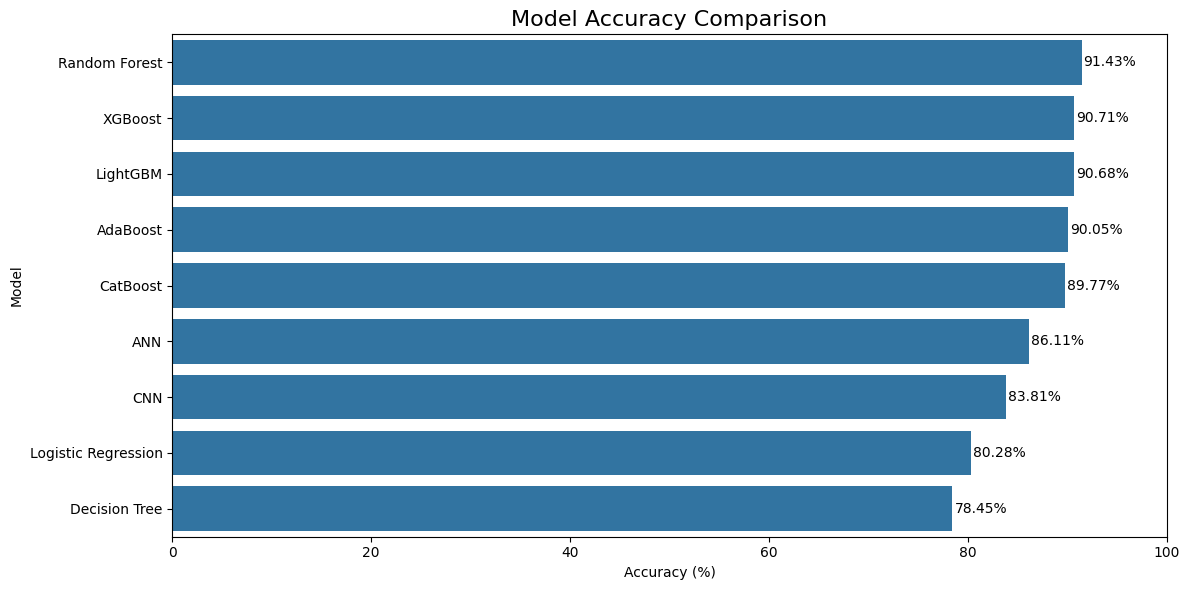

In [51]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=model_comparison_sorted,
    x="Accuracy (%)",
    y="Model"
)

plt.title("Model Accuracy Comparison", fontsize=16)
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")

# Show values
for i, value in enumerate(model_comparison_sorted["Accuracy (%)"]):
    plt.text(
        value + 0.2,
        i,
        f"{value:.2f}%",
        va="center"
    )

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=model_comparison.sort_values(
        "Class 0 Recall",
        ascending=False
    ),
    x="Class 0 Recall",
    y="Model"
)

plt.title("Class 0 Recall Comparison", fontsize=16)
plt.xlabel("Recall")
plt.ylabel("Model")

for i, value in enumerate(
    model_comparison.sort_values(
        "Class 0 Recall",
        ascending=False
    )["Class 0 Recall"]
):
    plt.text(
        value + 0.005,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.xlim(0, 0.30)
plt.tight_layout()
plt.show()